
# Optimisation Methods for Thermal Sciences (Interactive Notebook)


## 1. Optimisation Problems and Constraints

### Mathematical formulation

An optimisation problem can be written as:

\begin{align}
\min_{x} \quad & f(x; p) \\
\text{subject to} \quad & g_i(x) \le 0 \\
& x_{\min} \le x \le x_{\max}
\end{align}

Constraints originate from **physics**, **geometry**, **safety**, or **economics**.

---
### Visual interpretation of constraints

- The **objective** defines what is good or bad
- The **constraints** define where solutions are *allowed*


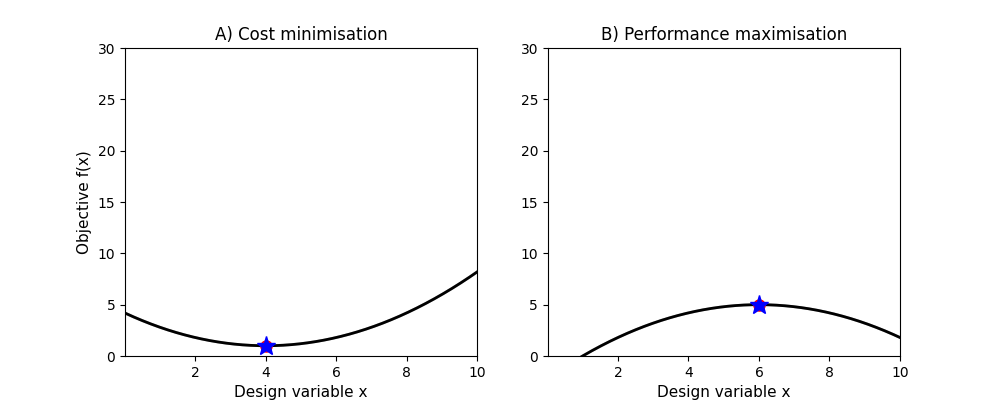

In [44]:
%matplotlib widget

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# -----------------------
# Global plotting style
# -----------------------
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
})

# -----------------------
# Strictly positive domain
# -----------------------
x = np.linspace(0.01, 10.0, 1600)

# -----------------------
# Figure
# -----------------------
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# Faded full curves
full_min_line, = axs[0].plot([], [], color="black", alpha=0.25)
full_max_line, = axs[1].plot([], [], color="black", alpha=0.25)

# Feasible curves only
avail_min_line, = axs[0].plot([], [], color="black")
avail_max_line, = axs[1].plot([], [], color="black")

# Optima markers
min_marker, = axs[0].plot([], [], "ro", markersize=8, zorder=10)
max_marker, = axs[1].plot([], [], "ro", markersize=8, zorder=10)

# Feasible (snapped) optima markers
min_feasible_marker, = axs[0].plot([], [], "b*", markersize=14, zorder=12)
max_feasible_marker, = axs[1].plot([], [], "b*", markersize=14, zorder=12)

# Labels
axs[0].set_title("A) Cost minimisation")
axs[0].set_xlabel("Design variable x")
axs[0].set_ylabel("Objective f(x)")
axs[0].set_xlim(np.amin(x), np.amax(x))
axs[0].set_ylim(0, 30)

axs[1].set_title("B) Performance maximisation")
axs[1].set_xlabel("Design variable x")
axs[1].set_ylim(0, 30)

# -----------------------
# Sliders
# -----------------------
a_slider = widgets.FloatSlider(
    min=0.05, max=1.0, step=0.05, value=0.2,
    description="Curvature"
)

offset_slider = widgets.FloatSlider(
    min=1.0, max=8.0, step=0.5, value=4.0,
    description="Offset"
)

plate_min_slider = widgets.FloatSlider(
    min=np.amin(x), max=np.amax(x), step=0.1, value=np.amin(x),
    description="Min x range"
)

plate_max_slider = widgets.FloatSlider(
    min=np.amin(x), max=np.amax(x), step=0.1, value=np.amax(x),
    description="Max x range"
)

display(
    widgets.VBox([
        a_slider,
        offset_slider,
        plate_min_slider,
        plate_max_slider
    ])
)

# -----------------------
# Manufacturability mask
# -----------------------
def manufacturable(xvals, A_min, A_max, tol=1e-6):
    """
    True if x = n * A with integer n ≥ 1 and A ∈ [A_min, A_max]
    """
    mask = np.zeros_like(xvals, dtype=bool)
    for n in range(1, 60):
        A = xvals / n
        mask |= (A >= A_min) & (A <= A_max) & (np.abs(A*n - xvals) < tol)
    return mask

# -----------------------
# Update function
# -----------------------
def update(*_):
    a = a_slider.value
    A_min = plate_min_slider.value
    A_max = plate_max_slider.value

    # Objective functions (guaranteed interior extrema)
    x_center = offset_slider.value
    delta = 2.0   # fixed separation between min and max locations
    
    f_min = a * (x - x_center)**2 + 1.0
    f_max = -a * (x - (x_center + delta))**2 + 5.0

    full_min_line.set_data(x, f_min)
    full_max_line.set_data(x, f_max)

    # True optima
    i_min = np.argmin(f_min)
    i_max = np.argmax(f_max)

    min_marker.set_data([x[i_min]], [f_min[i_min]])
    max_marker.set_data([x[i_max]], [f_max[i_max]])

    # Manufacturable x only (broken curves via NaN)
    mask = manufacturable(x, A_min, A_max)

    f_min_plot = np.where(mask, f_min, np.nan)
    f_max_plot = np.where(mask, f_max, np.nan)

    avail_min_line.set_data(x, f_min_plot)
    avail_max_line.set_data(x, f_max_plot)
    
    # --- Unconstrained optima ---
    i_min = np.argmin(f_min)
    i_max = np.argmax(f_max)
    
    x_min_opt = x[i_min]
    x_max_opt = x[i_max]
    
    min_marker.set_data([x_min_opt], [f_min[i_min]])
    max_marker.set_data([x_max_opt], [f_max[i_max]])
    
    # --- Manufacturability mask ---
    mask = manufacturable(x, A_min, A_max)
    
    # Break curves at infeasible points
    f_min_plot = np.where(mask, f_min, np.nan)
    f_max_plot = np.where(mask, f_max, np.nan)
    
    avail_min_line.set_data(x, f_min_plot)
    avail_max_line.set_data(x, f_max_plot)
    
    # --- SNAP OPTIMUM TO NEAREST FEASIBLE POINT ---
    if np.any(mask):
        x_feasible = x[mask]
    
        # Minimisation
        i_snap_min = np.argmin(np.abs(x_feasible - x_min_opt))
        x_snap_min = x_feasible[i_snap_min]
        y_snap_min = f_min[mask][i_snap_min]
    
        # Maximisation
        i_snap_max = np.argmin(np.abs(x_feasible - x_max_opt))
        x_snap_max = x_feasible[i_snap_max]
        y_snap_max = f_max[mask][i_snap_max]
    
        min_feasible_marker.set_data([x_snap_min], [y_snap_min])
        max_feasible_marker.set_data([x_snap_max], [y_snap_max])
    else:
        # No feasible design at all
        min_feasible_marker.set_data([], [])
        max_feasible_marker.set_data([], [])

    axs[0].relim()
    axs[0].autoscale_view(scalex=False)
    axs[1].relim()
    axs[1].autoscale_view(scalex=False)

    fig.canvas.draw_idle()

# -----------------------
# Connect sliders
# -----------------------
for s in (a_slider, offset_slider, plate_min_slider, plate_max_slider):
    s.observe(update, names="value")

# Initial draw
update()


## 2. Single Variable Optimisation – Thermal Insulation Thickness

# Heat Loss from an Insulated Cylindrical Pipe

## Geometry and Definitions

- $ r_1 $: outer radius of bare pipe (m)
- $ t $: insulation thickness (m)
- $ r_2 = r_1 + t $: outer radius with insulation (m)
- $L$ : Pipe length (m)
- $ T_s $: steam / pipe surface temperature (°C)
- $ T_a $: ambient temperature (°C)
- $ \lambda $: thermal conductivity of insulation (W/m·K)
- $ h $: external heat-transfer coefficient (W/m²·K)
- $ Q $: heat loss per unit length (W/m)

---

## Steady-State Heat Loss Equation

For a long insulated cylindrical pipe:

\begin{align}
Q = L 
\frac{2\pi (T_s - T_a)}
{
\displaystyle
\frac{\ln\!\left(\frac{r_2}{r_1}\right)}{\lambda}
+
\frac{1}{h\,r_2}
}
\end{align}

This expression represents:

- Conduction through the insulation layer
- External convection (and radiation, lumped into $ h $)

---

## Thermal Resistances

Conduction resistance:

\begin{align}
R_{\text{cond}} =
\frac{\ln(r_2/r_1)}{2\pi \lambda}
\end{align}

External convection resistance:

\begin{align}
R_{\text{conv}} =
\frac{1}{2\pi h r_2}
\end{align}

Total resistance:

\begin{align}
R_{\text{tot}} = R_{\text{cond}} + R_{\text{conv}}
\end{align}

---

## Costing Model

The economic objective is to minimise the **total annual cost**, defined as the sum of:

1. **Annual energy cost due to heat loss**
2. **Annualised insulation investment cost**

\begin{align}
\boxed{
J(t) = C_{\text{energy}}(t) + C_{\text{ins}}(t)
}
\end{align}

---

### 1. Annual Energy Cost

The heat loss $Q(t)$ results in fuel consumption over the operating period.

\begin{align}
C_{\text{energy}}(t)
=
c_e \;
\frac{Q(t)\,H}{1000}
\end{align}

where:

- $ c_e $: energy price (€/kWh)  
- $ H $: annual operating hours (h/year)  
- Division by 1000 converts W → kW  

This term **decreases with increasing insulation thickness**, but with diminishing returns.

---

### 2. Insulation Cost

The insulation cost is proportional to the **volume of insulation material**:

\begin{align}
C_{\text{ins}}(t)
=
c_i \;
\pi \left(r_2^2 - r_1^2\right) L
\end{align}

where:

- $ c_i $: insulation cost coefficient (€/m³)  
- $ \pi (r_2^2 - r_1^2)L $: insulation volume  

This term **increases monotonically** with insulation thickness.

---

## Final Optimisation Problem

The design problem can therefore be written as:

\begin{align}
\boxed{
\min_{t \ge 0}
\;
\left[
c_e \frac{Q(t)\,H}{1000}
\;+\;
c_i \pi \left(r_2^2 - r_1^2\right)
\right]
}
\end{align}

--- 

## Typical Insulation Materials and Thermal Conductivity

### Common Industrial Insulation

| Material | $ \lambda $ (W/m·K) |
|--------|------------------------|
| Mineral wool (rock / glass) | 0.035 – 0.050 |
| Fiberglass | 0.035 – 0.045 |
| Calcium silicate | 0.060 – 0.090 |
| Perlite insulation | 0.045 – 0.060 |
| Ceramic fiber blanket | 0.080 – 0.120 |
| Polyurethane foam (PUR / PIR) | 0.022 – 0.028 |


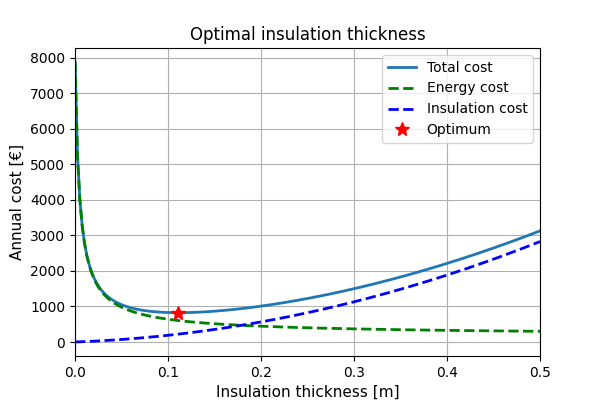

In [51]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# -----------------------
# Fixed physical parameters
# -----------------------
Ts = 180      # Steam temperature (°C)
Ta = 20       # Ambient temperature (°C)
r1 = 0.05     # Pipe outer radius (m)
h  = 10.0     # External heat transfer coefficient (W/m²·K)
L  = 20.0     # Pipe length (m)
hours = 8000  # Annual operation hours

# Thickness range
t = np.linspace(0.0001, 0.5, 200)
r2 = r1 + t

# -----------------------
# Figure (display once)
# -----------------------
fig, ax = plt.subplots(figsize=(6, 4))

total_line,        = ax.plot([], [], label="Total cost", linewidth=2)
energy_line,       = ax.plot([], [], "--", label="Energy cost", color="green")
insulation_line,   = ax.plot([], [], "--", label="Insulation cost", color="blue")
opt_point,         = ax.plot([], [], marker="*", label="Optimum", color="red", markersize=10, linewidth=0, zorder=10)

ax.set_xlabel("Insulation thickness [m]")
ax.set_ylabel("Annual cost [€]")
ax.set_title("Optimal insulation thickness")
ax.grid(True)
ax.legend()
ax.set_xlim([0, np.amax(t)])

# -----------------------
# Sliders
# -----------------------
k_slider = widgets.FloatSlider(
    min=0.03, max=0.10, step=0.005, value=0.045,
    description="Conductivity k", 
    style={'description_width': '100px'}
)

ce_slider = widgets.FloatSlider(
    min=0.03, max=0.12, step=0.005, value=0.10,
    description="Energy price", 
    style={'description_width': '100px'}
)

ci_slider = widgets.FloatSlider(
    min=50, max=500, step=10, value=150,
    description="Insulation cost", 
    style={'description_width': '100px'}
)

display(widgets.VBox([k_slider, ce_slider, ci_slider]))

# -----------------------
# Update function
# -----------------------
def update(*_):
    k  = k_slider.value
    ce = ce_slider.value
    ci = ci_slider.value

    # Heat loss per meter (W/m)
    Q = L * 2 * np.pi * (Ts - Ta) / (np.log(r2 / r1) / k + 1 / (h * r2))

    # Annual energy cost (€ / year)
    energy_cost = ce * Q * hours / 1000.0

    # Insulation cost (€)
    insulation_cost = ci * np.pi * (r2**2 - r1**2) * L

    # Total cost
    J = energy_cost + insulation_cost

    # Update curves
    total_line.set_data(t, J)
    energy_line.set_data(t, energy_cost)
    insulation_line.set_data(t, insulation_cost)

    # Optimal point
    idx = np.argmin(J)
    opt_point.set_data([t[idx]], [J[idx]])

    ax.relim()
    ax.autoscale_view(scalex=False)

    fig.canvas.draw_idle()

# -----------------------
# Connect sliders
# -----------------------
k_slider.observe(update, names="value")
ce_slider.observe(update, names="value")
ci_slider.observe(update, names="value")

# Initial draw
update()


---
## 3. Two Variables, Single Objective
### Heat exchanger: Two-variable thermal optimisation problem

---

## Objective Function

The total annual cost is modelled as the sum of three contributions:

\begin{align}
\boxed{
J(A, \Delta T)
=
c_A\,A
\;+\;
c_E\,\frac{Q}{U\,A\,\Delta T}
\;+\;
\lambda\,(\Delta T)^2
}
\end{align}

---

## Interpretation of the Cost Terms

### 1. Capital Cost (Area‑Dependent)

\begin{align}
C_{\text{cap}} = c_A\,A
\end{align}

- Represents the annualised investment cost of the heat exchanger  
- Increases linearly with heat‑transfer area  
- Encourages **smaller exchangers**

---

### 2. Energy Cost / Operating Penalty

\begin{align}
C_{\text{energy}} =
c_E\,\frac{Q}{U\,A\,\Delta T}
\end{align}

- Represents fuel or energy cost associated with finite heat‑transfer driving force  
- Decreases with increasing $A$ and $\Delta T$  
- Encourages **larger exchanger area** and **larger pinch point**

---

### 3. ΔT Exergy / Integration Penalty

\begin{align}
C_{\Delta T} = \lambda\,(\Delta T)^2
\end{align}

- Penalises excessively large temperature driving forces  
- Represents:
  - exergy destruction,
  - poor thermal integration,
  - loss of temperature matching with upstream and downstream processes  
- Prevents **unrealistically large $\Delta T$**

---


Decision variables:
- $A$: heat-transfer area
- $\Delta T$: pinch point,  minimum temperature approach

This function has a clear global minimum due to the trade-off
between capital cost and operating (energy) cost.

Assumptions:

- Heat duty: $Q = 1\,\text{MW}$
- Overall U: $U = 500\,\text{W/m²·K}$
- Area cost: $c_A = 120\,\texteuro / \text{m²·year}$
- Energy penalty: $c_E = 25{,}000\,\texteuro·\text{K/year}$


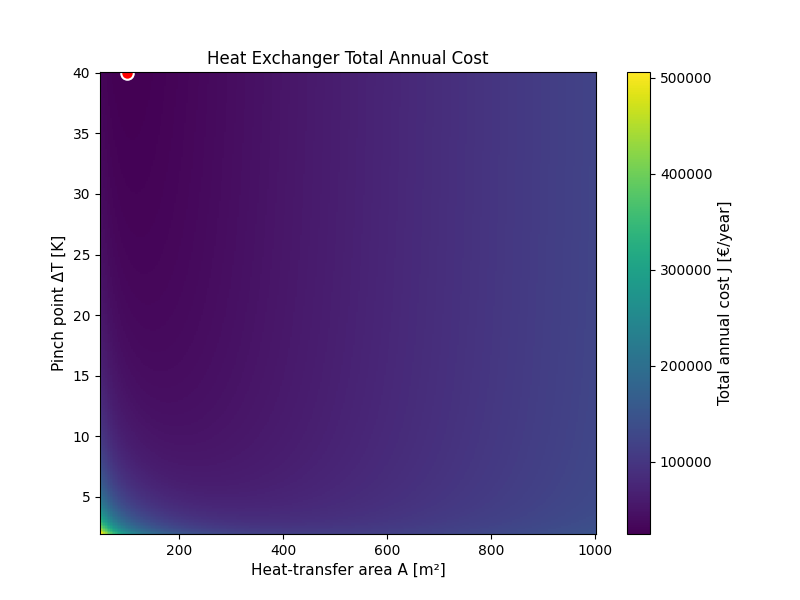

In [46]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# -------------------------------
# Fixed parameters
# -------------------------------
Q = 1e6  # Heat duty [W]

# -------------------------------
# Decision variable ranges
# -------------------------------
A = np.linspace(50, 1000, 300)
DT = np.linspace(2, 40, 300)
A_grid, DT_grid = np.meshgrid(A, DT)

# -------------------------------
# Initial parameter values
# -------------------------------
U0  = 500
cA0 = 120
cE0 = 25000
lam0 = 0.0   # ΔT penalty strength

# -------------------------------
# Initial cost
# -------------------------------
J = (
    cA0 * A_grid
    + (cE0 * Q) / (U0 * A_grid * DT_grid)
    + lam0 * DT_grid**2
)

# -------------------------------
# Figure
# -------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    A_grid,
    DT_grid,
    J,
    shading="auto",
    cmap="viridis"
)

ax.set_xlabel("Heat-transfer area A [m²]")
ax.set_ylabel("Pinch point ΔT [K]")
ax.set_title("Heat Exchanger Total Annual Cost")

cbar = fig.colorbar(pcm)
cbar.set_label("Total annual cost J [€/year]")

# Red marker for minimum
min_point, = ax.plot(
    [], [],
    marker="o",
    color="red",
    markersize=9,
    markeredgecolor="white",
    markeredgewidth=1.5
)

# -------------------------------
# Sliders
# -------------------------------
U_slider = widgets.FloatSlider(
    min=200, max=1200, step=50, value=U0,
    description="U [W/m²K]"
)

cA_slider = widgets.FloatSlider(
    min=50, max=300, step=10, value=cA0,
    description="cₐ [€/m²·yr]"
)

cE_slider = widgets.FloatSlider(
    min=5000, max=60000, step=1000, value=cE0,
    description="cₑ [€/yr·K]"
)

# ΔT penalty slider
lam_slider = widgets.FloatSlider(
    min=0.0, max=500.0, step=10.0, value=lam0,
    description="ΔT penalty λ"
)

display(widgets.VBox([U_slider, cA_slider, cE_slider, lam_slider]))

# -------------------------------
# Update function
# -------------------------------
def update(*_):
    U  = U_slider.value
    cA = cA_slider.value
    cE = cE_slider.value
    lam = lam_slider.value

    J_new = (
        cA * A_grid
        + (cE * Q) / (U * A_grid * DT_grid)
        + lam * DT_grid**2
    )

    # Update color mesh
    pcm.set_array(J_new.ravel())
    pcm.set_clim(J_new.min(), J_new.max())
    cbar.update_normal(pcm)

    # Global minimum
    idx = np.argmin(J_new)
    i, j = np.unravel_index(idx, J_new.shape)

    A_opt = A_grid[i, j]
    DT_opt = DT_grid[i, j]

    min_point.set_data([A_opt], [DT_opt])

    fig.canvas.draw_idle()

# -------------------------------
# Connect sliders
# -------------------------------
for s in (U_slider, cA_slider, cE_slider, lam_slider):
    s.observe(update, names="value")

# Initial draw
update()



## 4. Multiple Objectives and Pareto Optimality

### Dominance
A solution *A* dominates *B* if it is:
- no worse in all objectives
- strictly better in at least one

We construct the **Pareto front** by removing dominated solutions.


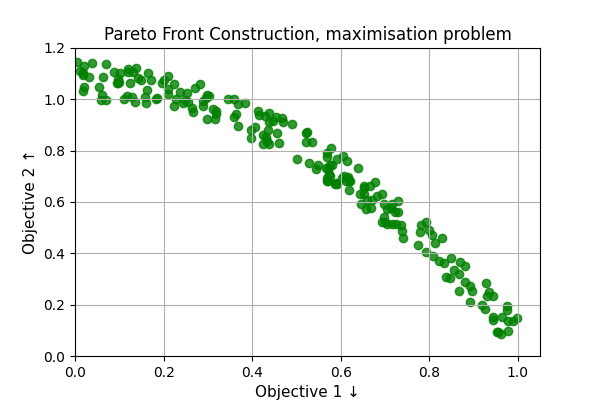

In [47]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display

# -------------------------------
# Data generation
# -------------------------------
np.random.seed(0)
n = 200

u = np.random.uniform(0, 1, n)
x = u
y = 1 - u**2 + 0.15 * np.random.rand(n)

points = np.column_stack((x, y))

# -------------------------------
# Pareto dominance (maximisation)
# -------------------------------
def dominates(a, b):
    return np.all(a >= b) and np.any(a > b)

pareto_mask = np.ones(n, dtype=bool)
for i in range(n):
    for j in range(n):
        if i != j and dominates(points[j], points[i]):
            pareto_mask[i] = False
            break

# Indices of Pareto‑optimal points
pareto_indices = np.where(pareto_mask)[0]

# -------------------------------
# Figure
# -------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

# Scatter (use explicit offsets update → reliable in ipympl)
sc = ax.scatter(x, y, c="green", alpha=0.8)

current_point, = ax.plot([], [], "o", color="blue", markersize=8)
vline, = ax.plot([], [], "--", color="black", linewidth=1)
hline, = ax.plot([], [], "--", color="black", linewidth=1)

# Pareto front line (initially hidden)
pareto_line, = ax.plot([], [], color="green", linewidth=4, label="Pareto front")

ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.2)
ax.set_xlabel("Objective 1 ↓")
ax.set_ylabel("Objective 2 ↑")
ax.set_title("Pareto Front Construction, maximisation problem")
ax.grid(True)


# -------------------------------
# Animation state
# -------------------------------
colors = np.array([[0, 0.6, 0, 0.8]] * n)  # RGBA green
anim = None

# -------------------------------
# Animation update
# -------------------------------
def update(i):
    # Mark dominated points
    if not pareto_mask[i]:
        colors[i] = [0.8, 0, 0, 0.8]  # red

    sc.set_facecolors(colors)

    # Highlight current point
    current_point.set_data([x[i]], [y[i]])
    vline.set_data([x[i], x[i]], [0, y[i]])
    hline.set_data([0, x[i]], [y[i], y[i]])

    # LAST FRAME: draw Pareto front
    if i == n - 1:
        pareto_pts = points[pareto_indices]
        # Sort for a clean front line
        pareto_pts = pareto_pts[np.argsort(pareto_pts[:, 0])]
        pareto_line.set_data(pareto_pts[:, 0], pareto_pts[:, 1])
        ax.legend()

    return sc, current_point, vline, hline, pareto_line

# -------------------------------
# Controls
# -------------------------------
start_button = widgets.Button(
    description="▶ Start Pareto Construction",
    button_style="success"
)

reset_button = widgets.Button(
    description="Reset",
    button_style="warning"
)

display(widgets.HBox([start_button, reset_button]))

# -------------------------------
# Callbacks
# -------------------------------
def start_animation(b):
    global anim
    reset(None)  # clean start every time

    anim = FuncAnimation(
        fig,
        update,
        frames=n,
        interval=60,
        blit=False,     
        repeat=False
    )
    fig.canvas.draw_idle()


def reset(b):
    global anim, colors

    if anim is not None:
        anim.event_source.stop()
        anim = None

    colors = np.array([[0, 0.6, 0, 0.8]] * n)
    sc.set_facecolors(colors)

    current_point.set_data([], [])
    vline.set_data([], [])
    hline.set_data([], [])
    pareto_line.set_data([], [])

    fig.canvas.draw_idle()


start_button.on_click(start_animation)
reset_button.on_click(reset)


## Solar Thermal versus Gas Heating: Multi‑Objective Trade‑off Analysis

A solar thermal system reduces the amount of gas required to satisfy a given heat demand.  
However, this reduction comes at the expense of a **higher capital investment**, typically associated with:

- collector area,
- storage capacity,
- installation and balance‑of‑plant costs.

As a result, solar system design is best treated as a **multi‑objective optimisation problem**, rather than a single aggregated cost minimisation.

---

## Multi‑Objective Formulation

The problem is formulated with **two competing objectives**:

\begin{align}
\begin{aligned}
\text{Minimise } & C_{\text{cap}}(A) \quad & \text{(capital investment)} \\
\text{Maximise } & S_{\text{gas}}(A) \quad & \text{(annual gas savings)}
\end{aligned}
\end{align}

where $A$ represents the **solar system size**.

There is generally **no single design** that simultaneously minimises cost and maximises savings.  
Instead, the solution consists of a **set of Pareto‑optimal designs**, each representing a different trade‑off.

---

## Capital Cost Objective

The annualised capital cost is assumed to scale linearly with system size:

\begin{align}
\boxed{
C_{\text{cap}}(A) = 400\,A + 1500
}
\end{align}

where:
- $A$ is the solar system size (dimensionless or area proxy),
- the constant term represents fixed installation costs,
- the linear term represents size‑dependent investment.

This objective increases monotonically with $A$.

---

## Gas Savings Objective

The annual gas savings are modelled as:


\begin{align}
\boxed{
S_{\text{gas}}(A)
=
p_{\text{gas}}
\;
Q_{\max}
\left(1 - e^{-kA}\right)
}
\end{align}

where:

- $Q_{\max}$ represents the **maximum useful solar thermal energy delivered per year** (kWh/year),
- $k$ is a **system effectiveness coefficient** accounting for collector efficiency, storage losses, and saturation effects,
- $p_{\text{gas}}$ is the gas price (€/kWh).

Typical values used in the analysis are:

- $Q_{\max} \approx 40\,000\text{–}80\,000 \;\text{kWh/year}$
- $k \approx 0.1$
- $p_{\text{gas}} \approx 0.04\text{–}0.12 \;\text{€/kWh}$


This objective:
- increases with $A$,
- saturates for large system sizes.

---

## Pareto Optimality

A design $A^\*$ is **Pareto‑optimal** if there exists no other design that:

- has **lower capital cost**, and
- provides **higher gas savings**.

All Pareto‑optimal designs form the **Pareto front**, which represents the best achievable trade‑offs between the two objectives.

---

## Role of Gas Price

The gas price $p_{\text{gas}}$ **reshapes the Pareto front**:

- At **low gas prices**, fuel savings grow slowly with system size, favouring smaller installations.
- At **high gas prices**, savings become more valuable, shifting the Pareto front toward larger solar systems.

Thus, gas price acts as a key economic driver in the decision‑making process.

---

## Capital Constraint and Decision Making

In practical applications, an additional constraint often applies:

\begin{align}
C_{\text{cap}}(A) \le C_{\text{available}}
\end{align}

This budget constraint selects a **preferred design** along the Pareto front and transforms the trade‑off into a concrete investment decision.

---

This analysis highlights that:

- Aggregating costs into a single scalar objective can obscure trade‑offs
- Pareto analysis provides a transparent basis for decision‑making
- Economic parameters (such as gas price and available capital) strongly influence the preferred design

The Pareto approach explicitly can reveal the cost–benefit structure underlying energy investment decisions.

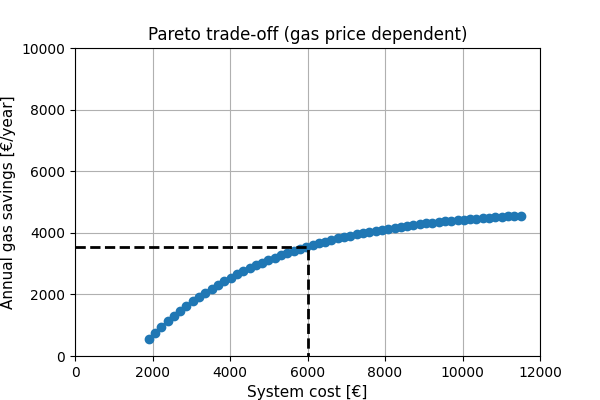

In [52]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# -----------------------
# Data
# -----------------------
A = np.linspace(1, 25, 60)

# -----------------------
# Figure (display once)
# -----------------------
fig, ax = plt.subplots(figsize=(6, 4))

tradeoff_line, = ax.plot([], [], '-o')
budget_line, = ax.plot([], [], '--', color='k')

ax.set_xlim(0, 12000)
ax.set_ylim(0, 10000)

ax.set_xlabel('System cost [€]')
ax.set_ylabel('Annual gas savings [€/year]')
ax.set_title('Pareto trade-off (gas price dependent)')
ax.grid(True)

# -----------------------
# Sliders
# -----------------------
price_slider = widgets.FloatSlider(
    min=0.03, max=0.15, step=0.005,
    value=0.08, description='Gas price'
)

capital_slider = widgets.FloatSlider(
    min=1000, max=12000, step=100,
    value=6000, description='Capital available'
)

display(widgets.VBox([capital_slider, price_slider]))

# -----------------------
# Update function
# -----------------------
def update(*_):
    price = price_slider.value
    capital_available = capital_slider.value

    Q_max = 60000   # kWh/year, realistic solar thermal contribution
    k = 0.12        # saturation coefficient
    
    savings = price * Q_max * (1 - np.exp(-k * A))  # €/year

    cost = 400 * A + 1500

    # Update Pareto curve
    tradeoff_line.set_data(cost, savings)

    # Budget constraint
    affordable = cost < capital_available
    if np.any(affordable):
        savings_available = savings[affordable][-1]
    else:
        savings_available = 0

    budget_line.set_data(
        [0, capital_available, capital_available],
        [savings_available, savings_available, 0]
    )

    fig.canvas.draw_idle()

# -----------------------
# Connect widgets
# -----------------------
price_slider.observe(update, names="value")
capital_slider.observe(update, names="value")

# Initialize
update()


## 5. Gradient-Based Optimisation

The gradient $
\nabla f$ provides **local slope information**.

For differentiable functions:

- $\nabla f = 0$ → candidate optimum
- Sign tells us *which direction improves the objective*


FloatSlider(value=0.0, description='Thickness', max=0.6, readout_format='.3f', step=0.0015037593984962405)

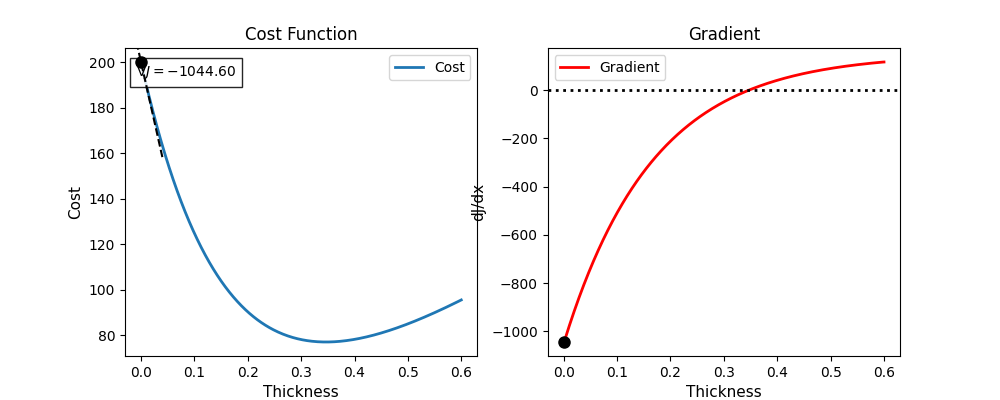

In [53]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# --------------------
# Data
# --------------------
x = np.linspace(0, 0.6, 400)
J = 200*np.exp(-6*x) + 150*x
dJ = np.gradient(J, x)

# --------------------
# Figure: two panels
# --------------------
fig, (ax_cost, ax_grad) = plt.subplots(
    1, 2, figsize=(10, 4), sharex=True
)

# ---- Left: Cost ----
ax_cost.plot(x, J, label="Cost")
ax_cost.set_xlabel("Thickness")
ax_cost.set_ylabel("Cost")
ax_cost.set_title("Cost Function")
ax_cost.legend()

# ---- Right: Gradient ----
ax_grad.plot(x, dJ, color="red", label="Gradient")
ax_grad.axhline(0, color="black", linestyle=":", linewidth=2)
ax_grad.set_xlabel("Thickness")
ax_grad.set_ylabel("dJ/dx")
ax_grad.set_title("Gradient")
ax_grad.legend()

# --------------------
# Persistent artists
# --------------------
# Cost panel
cost_marker, = ax_cost.plot([], [], "ko", ms=8, zorder=5)
tangent, = ax_cost.plot([], [], "k--", lw=1.5, zorder=4)
grad_text = ax_cost.text(
    0.03, 0.95, "",
    transform=ax_cost.transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

# Gradient panel
grad_marker, = ax_grad.plot([], [], "ko", ms=8, zorder=5)

# --------------------
# Slider
# --------------------
slider = widgets.FloatSlider(
    value=x[0],
    min=x.min(),
    max=x.max(),
    step=x[1] - x[0],
    description="Thickness",
    readout_format=".3f",
    continuous_update=True
)

# --------------------
# Update function
# --------------------
def update(change):
    x0 = change["new"]
    i = np.argmin(np.abs(x - x0))

    # ---- Cost marker ----
    cost_marker.set_data([x[i]], [J[i]])

    # ---- Tangent line ----
    dx = 0.04
    xt = np.array([x[i] - dx, x[i] + dx])
    yt = J[i] + dJ[i] * (xt - x[i])
    tangent.set_data(xt, yt)

    # ---- Gradient text ----
    grad_text.set_text(rf"$\nabla J = {dJ[i]:.2f}$")

    # ---- Gradient marker ----
    grad_marker.set_data([x[i]], [dJ[i]])

    fig.canvas.draw_idle()

slider.observe(update, names="value")
display(slider)

# Initialize once
update({"new": slider.value})

## Gradient Descent: Basic Idea

Gradient descent is an iterative optimisation method used to **minimise a differentiable objective function** by repeatedly moving in the direction of **steepest descent**.

---

### Method

Given an objective function $ f(x) $, the update rule is:

\begin{align}
x_{k+1} = x_k - \alpha \, \nabla f(x_k)
\end{align}

where:

- $ x_k $ is the current estimate of the optimum,
- $ \nabla f(x_k) $ is the gradient (slope) of the objective at $ x_k $,
- $ \alpha > 0 $ is the **learning rate** (step size).

---

### Interpretation

- The gradient indicates the direction of variation of the objective function.
- Moving towards positive (maximisation) or negative (minimisation) gradients progresses towards teh optimum.
- The learning rate controls how far each step moves.

---

### Key properties

- If $ \alpha $ is **too small**, convergence is slow.
- If $ \alpha $ is **too large**, the method may oscillate or diverge.
- Convergence typically occurs when the gradient approaches zero.

---

### Limitations

- Its performance depends strongly on scaling and step‑size selection.
- It requires the objective to be **smooth and differentiable**.

Despite these limitations, gradient descent is a fundamental tool in optimisation and serves as the basis for many advanced algorithms in engineering and machine learning.

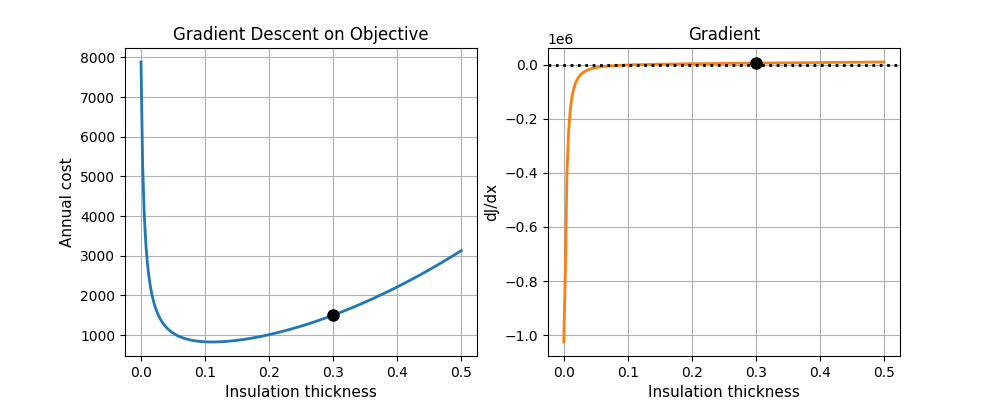

In [56]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display

# ----------------------------
# Function and gradient
# ----------------------------
x = np.linspace(0.0001, 0.5, 200)

Ts, Ta = 180, 20
r1, h, L = 0.05, 10.0, 20.0
hours = 8000
k, ce, ci = 0.045, 0.10, 150

r2 = r1 + x

Q = 2 * np.pi * (Ts - Ta) / (np.log(r2 / r1) / k + 1 / (h * r2))
energy_cost = ce * Q * L * hours / 1000.0
insulation_cost = ci * np.pi * (r2**2 - r1**2) * L

f = energy_cost + insulation_cost
df_dx = np.gradient(f, x)

def fval(x0):
    return np.interp(x0, x, f)

def grad(x0):
    return np.interp(x0, x, df_dx)

# ----------------------------
# Figure
# ----------------------------
fig, (ax_f, ax_g) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax_f.plot(x, f, lw=2)
ax_f.set_title("Gradient Descent on Objective")
ax_f.set_xlabel("Insulation thickness")
ax_f.set_ylabel("Annual cost")
ax_f.grid(True)

ax_g.plot(x, df_dx, lw=2, color="tab:orange")
ax_g.axhline(0, color="black", linestyle=":")
ax_g.set_xlabel("Insulation thickness")
ax_g.set_ylabel("dJ/dx")
ax_g.set_title("Gradient")
ax_g.grid(True)

pt_f, = ax_f.plot([], [], "ko", ms=8)
path_f, = ax_f.plot([], [], "k-", lw=1.5, alpha=0.6)

pt_g, = ax_g.plot([], [], "ko", ms=8)
path_g, = ax_g.plot([], [], "k-", lw=1.5, alpha=0.6)

# ----------------------------
# Controls
# ----------------------------
x_slider = widgets.FloatSlider(
    value=0.30,
    min=x.min(),
    max=x.max(),
    step=x[1] - x[0],
    description="Start x",
    readout_format=".4f"
)

lr_slider = widgets.FloatLogSlider(
    value=1e-5,
    base=10,
    min=-7,
    max=-3,
    step=0.1,
    description="Learning rate"
)

start_button = widgets.Button(
    description="Start Descent",
    button_style="success"
)

reset_button = widgets.Button(
    description="Reset",
    button_style="warning"
)

display(widgets.VBox([
    x_slider,
    lr_slider,
    widgets.HBox([start_button, reset_button])
]))

# ----------------------------
# Gradient descent parameters
# ----------------------------
max_steps = 80
xs, fs, gs = [], [], []
anim = None

# ----------------------------
# Preview start position
# ----------------------------
def update_start(change):
    x0 = x_slider.value
    pt_f.set_data([x0], [fval(x0)])
    pt_g.set_data([x0], [grad(x0)])
    path_f.set_data([], [])
    path_g.set_data([], [])
    fig.canvas.draw_idle()

x_slider.observe(update_start, names="value")
update_start(None)

# ----------------------------
# Animation functions
# ----------------------------
def init_anim():
    path_f.set_data([], [])
    path_g.set_data([], [])
    return pt_f, pt_g, path_f, path_g

def animate(frame):
    lr = lr_slider.value   # learning rate from slider

    if frame == 0:
        xs.clear()
        fs.clear()
        gs.clear()
        xs.append(x_slider.value)
    else:
        xs.append(xs[-1] - lr * grad(xs[-1]))

    fs.append(fval(xs[-1]))
    gs.append(grad(xs[-1]))

    pt_f.set_data([xs[-1]], [fs[-1]])
    pt_g.set_data([xs[-1]], [gs[-1]])

    path_f.set_data(xs, fs)
    path_g.set_data(xs, gs)

    return pt_f, pt_g, path_f, path_g

# ----------------------------
# Button callbacks
# ----------------------------
def start_animation(b):
    global anim
    if anim is not None:
        anim.event_source.stop()

    anim = FuncAnimation(
        fig,
        animate,
        frames=max_steps,
        init_func=init_anim,
        interval=150,
        blit=False,
        repeat=False
    )
    fig.canvas.draw_idle()

def reset(b):
    global anim
    if anim is not None:
        anim.event_source.stop()
        anim = None
    update_start(None)

start_button.on_click(start_animation)
reset_button.on_click(reset)



## 6. Local vs Global Optima

Real objective functions may have **multiple extrema**.
Optimisation algorithms may converge to *local* solutions.


FloatSlider(value=-4.0, description='x', max=4.0, min=-4.0, step=0.013355592654423987)

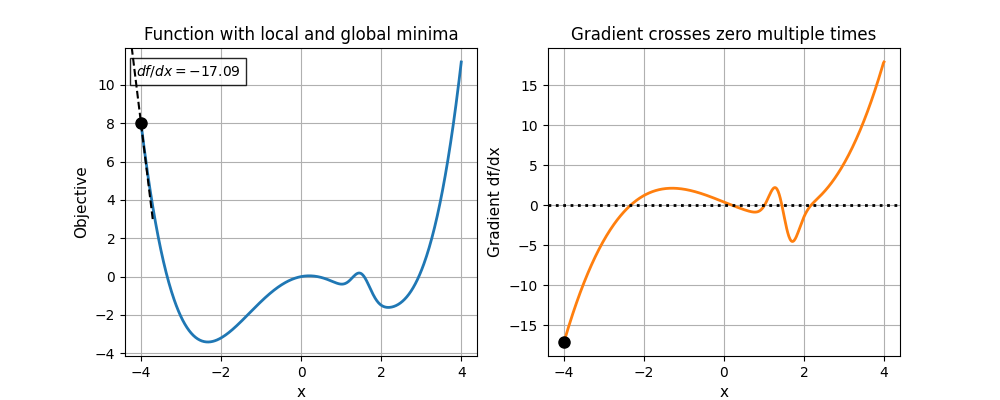

In [58]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# --------------------
# Domain and function
# --------------------
x = np.linspace(-4, 4, 600)

f = (
    0.1 * x**4 - x**2 + 0.4 * x + 1.3 * np.exp(-(x - 1.5)**2 / 0.1)
)

# Numerical gradient
df_dx = np.gradient(f, x)

# --------------------
# Figure: two panels
# --------------------
fig, (ax_f, ax_g) = plt.subplots(
    1, 2, figsize=(10, 4), sharex=True
)

# ---- Left panel: objective ----
ax_f.plot(x, f, linewidth=2)
ax_f.set_xlabel("x")
ax_f.set_ylabel("Objective")
ax_f.set_title("Function with local and global minima")
ax_f.grid(True)

# ---- Right panel: gradient ----
ax_g.plot(x, df_dx, linewidth=2, color="tab:orange")
ax_g.axhline(0, color="black", linestyle=":", linewidth=2)
ax_g.set_xlabel("x")
ax_g.set_ylabel("Gradient df/dx")
ax_g.set_title("Gradient crosses zero multiple times")
ax_g.grid(True)

# --------------------
# Persistent artists
# --------------------
# Objective panel
f_marker, = ax_f.plot([], [], "ko", ms=8, zorder=5)
tangent,  = ax_f.plot([], [], "k--", lw=1.5, zorder=4)

grad_text = ax_f.text(
    0.03, 0.95, "",
    transform=ax_f.transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

# Gradient panel
g_marker, = ax_g.plot([], [], "ko", ms=8, zorder=5)

# --------------------
# Slider
# --------------------
slider = widgets.FloatSlider(
    value=x[0],
    min=x.min(),
    max=x.max(),
    step=x[1] - x[0],
    description="x",
    readout_format=".2f",
    continuous_update=True
)

# --------------------
# Update function
# --------------------
def update(change):
    x0 = change["new"]
    i = np.argmin(np.abs(x - x0))

    # ---- Objective marker ----
    f_marker.set_data([x[i]], [f[i]])

    # ---- Tangent line ----
    dx = 0.3
    xt = np.array([x[i] - dx, x[i] + dx])
    yt = f[i] + df_dx[i] * (xt - x[i])
    tangent.set_data(xt, yt)

    # ---- Gradient text ----
    grad_text.set_text(rf"$df/dx = {df_dx[i]:.2f}$")

    # ---- Gradient marker ----
    g_marker.set_data([x[i]], [df_dx[i]])

    fig.canvas.draw_idle()

slider.observe(update, names="value")
display(slider)

# Initialize once
update({"new": slider.value})

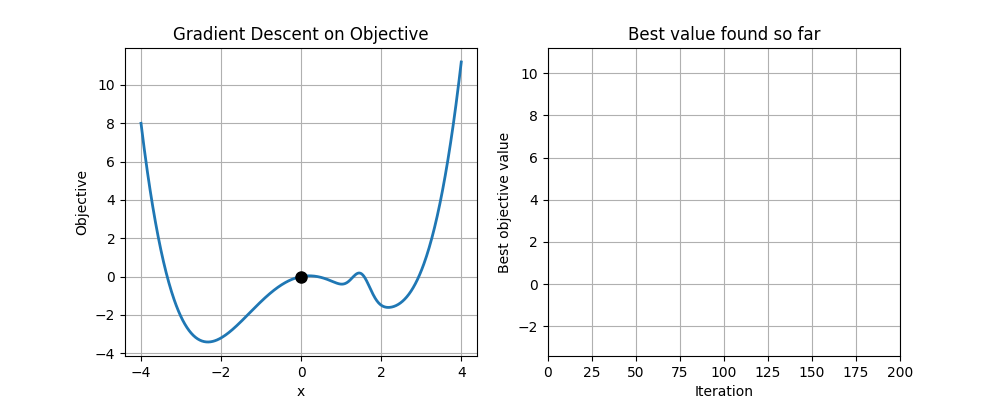

In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display

BEST_UPDATE_EVERY = 5   # update right plot every 5 frames

# ----------------------------
# Function and gradient
# ----------------------------
x = np.linspace(-4, 4, 600)

f = (
    0.1 * x**4 - x**2 + 0.4 * x
    + 1.3 * np.exp(-(x - 1.5)**2 / 0.1)
)

df_dx = np.gradient(f, x)

def fval(x0):
    return np.interp(x0, x, f)

def grad(x0):
    return np.interp(x0, x, df_dx)

# ----------------------------
# Figure
# ----------------------------
fig, (ax_f, ax_best) = plt.subplots(1, 2, figsize=(10, 4))

# ---- Left: objective trajectory ----
ax_f.plot(x, f, lw=2)
ax_f.set_xlabel("x")
ax_f.set_ylabel("Objective")
ax_f.set_title("Gradient Descent on Objective")
ax_f.grid(True)

# ---- Right: best value found ----
ax_best.set_xlabel("Iteration")
ax_best.set_ylabel("Best objective value")
ax_best.set_title("Best value found so far")
ax_best.grid(True)

# ----------------------------
# Artists
# ----------------------------
# Left panel
pt_f, = ax_f.plot([], [], "ko", ms=8)
path_f, = ax_f.plot([], [], "k-", lw=1.5, alpha=0.6)

# Right panel
best_line, = ax_best.plot([], [], "tab:blue", lw=2)
best_point, = ax_best.plot([], [], "ko")

# ----------------------------
# Controls
# ----------------------------
x_slider = widgets.FloatSlider(
    value=0.0,
    min=x.min(),
    max=x.max(),
    step=x[1] - x[0],
    description="Start x",
    readout_format=".2f"
)

lr_slider = widgets.FloatLogSlider(
    value=1e-2,
    base=10,
    min=-4,
    max=-1,
    step=0.1,
    description="Learning rate α"
)

start_button = widgets.Button(
    description="Start Descent",
    button_style="success"
)

reset_button = widgets.Button(
    description="Reset",
    button_style="warning"
)

display(widgets.VBox([
    x_slider,
    lr_slider,
    widgets.HBox([start_button, reset_button])
]))

# ----------------------------
# Gradient descent parameters
# ----------------------------
max_steps = 200

# ----------------------------
# Animation state
# ----------------------------
xs, fs = [], []
best_vals = []
anim = None

# ----------------------------
# Preview start position
# ----------------------------
def update_start(change):
    x0 = x_slider.value
    pt_f.set_data([x0], [fval(x0)])
    path_f.set_data([], [])

    best_line.set_data([], [])
    best_point.set_data([], [])
    ax_best.set_xlim(0, max_steps)
    ax_best.set_ylim(f.min(), f.max())

    fig.canvas.draw_idle()

x_slider.observe(update_start, names="value")
update_start(None)

# ----------------------------
# Animation functions
# ----------------------------
def init_anim():
    path_f.set_data([], [])
    best_line.set_data([], [])
    best_point.set_data([], [])
    return pt_f, path_f, best_line, best_point

def animate(frame):
    alpha = lr_slider.value

    if frame == 0:
        xs.clear()
        fs.clear()
        best_vals.clear()
        xs.append(x_slider.value)
    else:
        xs.append(xs[-1] - alpha * grad(xs[-1]))

    f_current = fval(xs[-1])
    fs.append(f_current)
    best_vals.append(min(best_vals[-1], f_current) if best_vals else f_current)

    # ---- Left plot (every frame) ----
    pt_f.set_data([xs[-1]], [fs[-1]])
    path_f.set_data(xs, fs)

    # ---- Right plot (throttled) ----
    if frame % BEST_UPDATE_EVERY == 0:
        iters = range(len(best_vals))
        best_line.set_data(iters, best_vals)
        best_point.set_data(iters[-1], best_vals[-1])

    return pt_f, path_f, best_line, best_point

# ----------------------------
# Button callbacks
# ----------------------------
def start_animation(b):
    global anim
    if anim is not None:
        anim.event_source.stop()

    anim = FuncAnimation(
        fig,
        animate,
        frames=max_steps,
        init_func=init_anim,
        interval=20,
        blit=False,
        repeat=False
    )
    fig.canvas.draw_idle()

def reset(b):
    global anim
    if anim is not None:
        anim.event_source.stop()
        anim = None
    update_start(None)

start_button.on_click(start_animation)
reset_button.on_click(reset)


## 7. Noise and Gradient Failure

With noisy evaluations, gradients become unreliable.

This motivates stochastic and population-based approaches.


FloatSlider(value=-4.0, description='x', max=4.0, min=-4.0, step=0.013355592654423987)

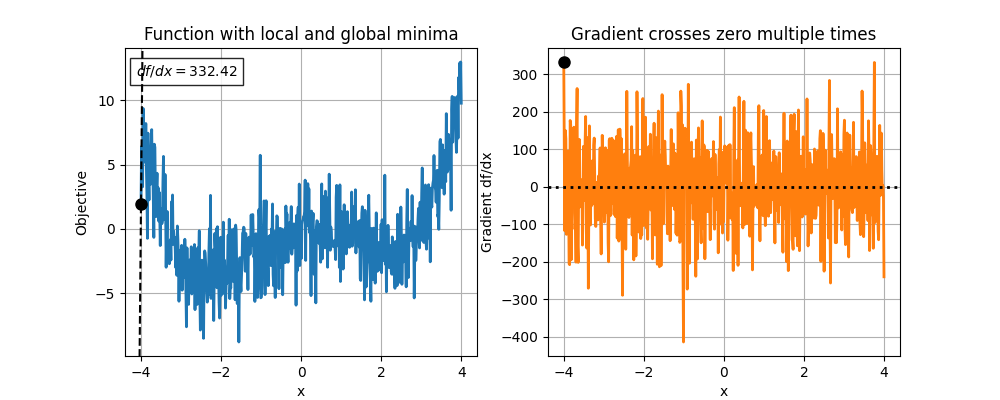

In [2]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# --------------------
# Domain and function
# --------------------
x = np.linspace(-4, 4, 600)
noise = np.random.normal(0, 2, size=len(x))
def cost(x):
    return 0.1 * x**4 - x**2 + 0.4 * x + 1.3 * np.exp(-(x - 1.5)**2 / 0.1)

f = cost(x) + noise

# Numerical gradient
df_dx = np.gradient(f, x)

# --------------------
# Figure: two panels
# --------------------
fig, (ax_f, ax_g) = plt.subplots(
    1, 2, figsize=(10, 4), sharex=True
)

# ---- Left panel: objective ----
ax_f.plot(x, f, linewidth=2)
ax_f.set_xlabel("x")
ax_f.set_ylabel("Objective")
ax_f.set_title("Function with local and global minima")
ax_f.grid(True)

# ---- Right panel: gradient ----
ax_g.plot(x, df_dx, linewidth=2, color="tab:orange")
ax_g.axhline(0, color="black", linestyle=":", linewidth=2)
ax_g.set_xlabel("x")
ax_g.set_ylabel("Gradient df/dx")
ax_g.set_title("Gradient crosses zero multiple times")
ax_g.grid(True)

# --------------------
# Persistent artists
# --------------------
# Objective panel
f_marker, = ax_f.plot([], [], "ko", ms=8, zorder=5)
tangent,  = ax_f.plot([], [], "k--", lw=1.5, zorder=4)

grad_text = ax_f.text(
    0.03, 0.95, "",
    transform=ax_f.transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

# Gradient panel
g_marker, = ax_g.plot([], [], "ko", ms=8, zorder=5)

# --------------------
# Slider
# --------------------
slider = widgets.FloatSlider(
    value=x[0],
    min=x.min(),
    max=x.max(),
    step=x[1] - x[0],
    description="x",
    readout_format=".2f",
    continuous_update=True
)

# --------------------
# Update function
# --------------------
def update(change):
    x0 = change["new"]
    i = np.argmin(np.abs(x - x0))

    # ---- Objective marker ----
    f_marker.set_data([x[i]], [f[i]])

    # ---- Tangent line ----
    dx = 0.3
    xt = np.array([x[i] - dx, x[i] + dx])
    yt = f[i] + df_dx[i] * (xt - x[i])
    tangent.set_data(xt, yt)

    # ---- Gradient text ----
    grad_text.set_text(rf"$df/dx = {df_dx[i]:.2f}$")

    # ---- Gradient marker ----
    g_marker.set_data([x[i]], [df_dx[i]])

    fig.canvas.draw_idle()

slider.observe(update, names="value")
display(slider)

# Initialize once
update({"new": slider.value})

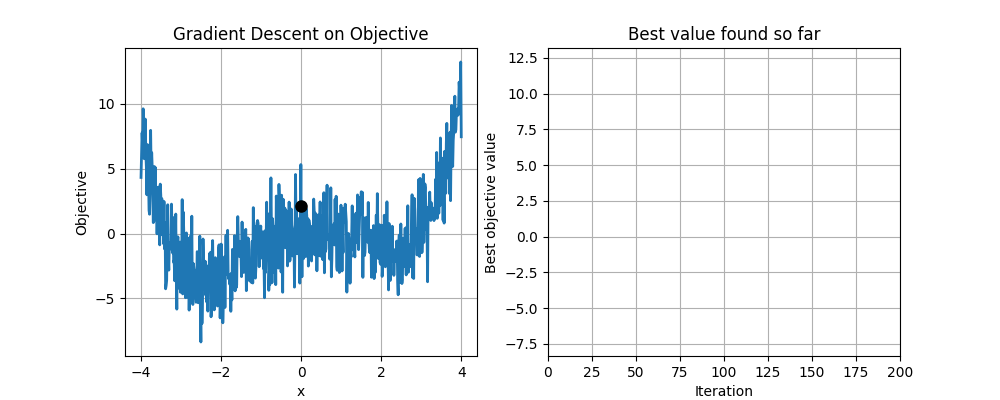

In [3]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display

BEST_UPDATE_EVERY = 5   # update right plot every 5 frames

# ----------------------------
# Function and gradient
# ----------------------------
x = np.linspace(-4, 4, 600)
noise = np.random.normal(0, 2, size=len(x))
def cost(x):
    return 0.1 * x**4 - x**2 + 0.4 * x + 1.3 * np.exp(-(x - 1.5)**2 / 0.1)

f = cost(x) + noise

df_dx = np.gradient(f, x)

def fval(x0):
    return np.interp(x0, x, f)

def grad(x0):
    return np.interp(x0, x, df_dx)

# ----------------------------
# Figure
# ----------------------------
fig, (ax_f, ax_best) = plt.subplots(1, 2, figsize=(10, 4))

# ---- Left: objective trajectory ----
ax_f.plot(x, f, lw=2)
ax_f.set_xlabel("x")
ax_f.set_ylabel("Objective")
ax_f.set_title("Gradient Descent on Objective")
ax_f.grid(True)

# ---- Right: best value found ----
ax_best.set_xlabel("Iteration")
ax_best.set_ylabel("Best objective value")
ax_best.set_title("Best value found so far")
ax_best.grid(True)

# ----------------------------
# Artists
# ----------------------------
# Left panel
pt_f, = ax_f.plot([], [], "ko", ms=8)
path_f, = ax_f.plot([], [], "k-", lw=1.5, alpha=0.6)

# Right panel
best_line, = ax_best.plot([], [], "tab:blue", lw=2)
best_point, = ax_best.plot([], [], "ko")

# ----------------------------
# Controls
# ----------------------------
x_slider = widgets.FloatSlider(
    value=0.0,
    min=x.min(),
    max=x.max(),
    step=x[1] - x[0],
    description="Start x",
    readout_format=".2f"
)

lr_slider = widgets.FloatLogSlider(
    value=1e-2,
    base=10,
    min=-4,
    max=-1,
    step=0.1,
    description="Learning rate α"
)

start_button = widgets.Button(
    description="Start Descent",
    button_style="success"
)

reset_button = widgets.Button(
    description="Reset",
    button_style="warning"
)

display(widgets.VBox([
    x_slider,
    lr_slider,
    widgets.HBox([start_button, reset_button])
]))

# ----------------------------
# Gradient descent parameters
# ----------------------------
max_steps = 200

# ----------------------------
# Animation state
# ----------------------------
xs, fs = [], []
best_vals = []
anim = None

# ----------------------------
# Preview start position
# ----------------------------
def update_start(change):
    x0 = x_slider.value
    pt_f.set_data([x0], [fval(x0)])
    path_f.set_data([], [])

    best_line.set_data([], [])
    best_point.set_data([], [])
    ax_best.set_xlim(0, max_steps)
    ax_best.set_ylim(f.min(), f.max())

    fig.canvas.draw_idle()

x_slider.observe(update_start, names="value")
update_start(None)

# ----------------------------
# Animation functions
# ----------------------------
def init_anim():
    path_f.set_data([], [])
    best_line.set_data([], [])
    best_point.set_data([], [])
    return pt_f, path_f, best_line, best_point

def animate(frame):
    alpha = lr_slider.value

    if frame == 0:
        xs.clear()
        fs.clear()
        best_vals.clear()
        xs.append(x_slider.value)
    else:
        xs.append(xs[-1] - alpha * grad(xs[-1]))

    f_current = fval(xs[-1])
    fs.append(f_current)
    best_vals.append(min(best_vals[-1], f_current) if best_vals else f_current)

    # ---- Left plot (every frame) ----
    pt_f.set_data([xs[-1]], [fs[-1]])
    path_f.set_data(xs, fs)

    # ---- Right plot (throttled) ----
    if frame % BEST_UPDATE_EVERY == 0:
        iters = range(len(best_vals))
        best_line.set_data(iters, best_vals)
        best_point.set_data(iters[-1], best_vals[-1])

    return pt_f, path_f, best_line, best_point

# ----------------------------
# Button callbacks
# ----------------------------
def start_animation(b):
    global anim
    if anim is not None:
        anim.event_source.stop()

    anim = FuncAnimation(
        fig,
        animate,
        frames=max_steps,
        init_func=init_anim,
        interval=20,
        blit=False,
        repeat=False
    )
    fig.canvas.draw_idle()

def reset(b):
    global anim
    if anim is not None:
        anim.event_source.stop()
        anim = None
    update_start(None)

start_button.on_click(start_animation)
reset_button.on_click(reset)


## 8. Gradient-Free Optimisation – Random Sampling

Random sampling does not rely on gradient informationp.


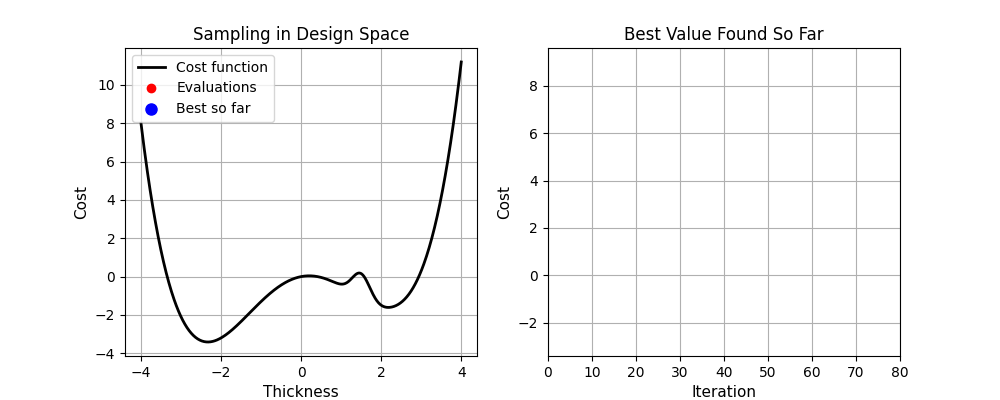

In [68]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display

# -----------------------------
# Previous insulation data
# -----------------------------
def cost(x):
    return 0.1 * x**4 - x**2 + 0.4 * x + 1.3 * np.exp(-(x - 1.5)**2 / 0.1)

x = np.linspace(-4, 4, 600)
J = cost(x)

# Random sampling in design space
np.random.seed(0)
samples = np.random.uniform(np.amin(x), np.amax(x), 80)
vals = cost(samples)

# -----------------------------
# Figure
# -----------------------------
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# ---- Left: sampling in design space ----
axs[0].plot(x, J, color="black", label="Cost function")
evals_line, = axs[0].plot([], [], "ro", label="Evaluations")
best_pt, = axs[0].plot([], [], "bo", markersize=8, label="Best so far")

axs[0].set_title("Sampling in Design Space")
axs[0].set_xlabel("Thickness")
axs[0].set_ylabel("Cost")
axs[0].legend()
axs[0].grid(True)

# ---- Right: best-so-far curve ----
best_vals = []
best_line, = axs[1].plot([], [], "-o")

axs[1].set_xlim(0, len(samples))
axs[1].set_ylim(vals.min(), vals.max())
axs[1].set_title("Best Value Found So Far")
axs[1].set_xlabel("Iteration")
axs[1].set_ylabel("Cost")
axs[1].grid(True)


# -----------------------------
# Animation update
# -----------------------------
def update(i):
    # All evaluations so far
    evals_line.set_data(samples[:i+1], vals[:i+1])

    # Best so far
    best_idx = np.argmin(vals[:i+1])
    best_pt.set_data([samples[best_idx]], [vals[best_idx]])

    best_vals.append(vals[best_idx])
    best_line.set_data(range(len(best_vals)), best_vals)

    return evals_line, best_pt, best_line

# -----------------------------
# Controls
# -----------------------------
start_button = widgets.Button(
    description="Start Sampling",
    button_style="success"
)

reset_button = widgets.Button(
    description="Reset",
    button_style="warning"
)

display(widgets.HBox([start_button, reset_button]))

# -----------------------------
# Animation control
# -----------------------------
anim = None

def start_animation(b):
    global anim, best_vals
    best_vals = []

    anim = FuncAnimation(
        fig,
        update,
        frames=len(samples),
        interval=150,
        blit=False,      # IMPORTANT for ipympl stability
        repeat=False
    )
    fig.canvas.draw_idle()

def reset(b):
    global anim, best_vals
    if anim is not None:
        anim.event_source.stop()
        anim = None

    evals_line.set_data([], [])
    best_pt.set_data([], [])
    best_vals = []
    best_line.set_data([], [])
    fig.canvas.draw_idle()

start_button.on_click(start_animation)
reset_button.on_click(reset)

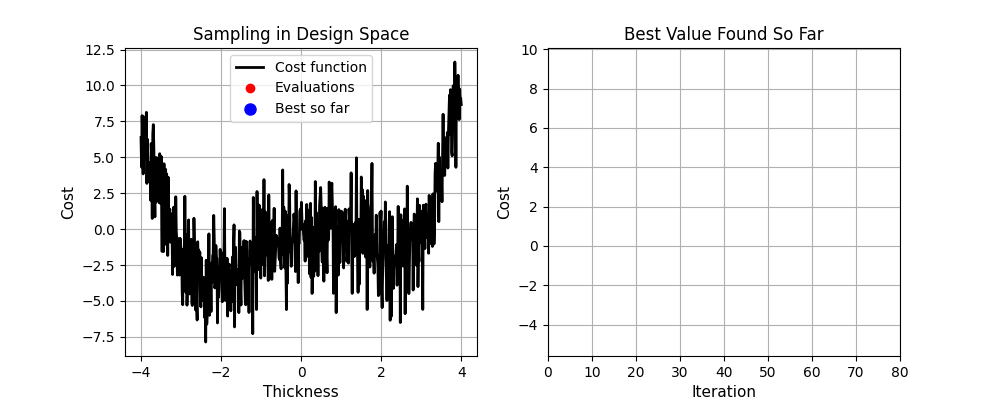

In [72]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display

# -----------------------------
# Previous insulation data
# -----------------------------
x = np.linspace(-4, 4, 600)
noise = np.random.normal(0, 2, size=len(x))
def cost(x):
    return 0.1 * x**4 - x**2 + 0.4 * x + 1.3 * np.exp(-(x - 1.5)**2 / 0.1) +noise



J = cost(x)
dJ = np.gradient(J, x)

# Random sampling in design space
np.random.seed(0)
samples = np.random.uniform(np.amin(x), np.amax(x), 80)
vals = np.interp(samples, x, J)

# -----------------------------
# Figure
# -----------------------------
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# ---- Left: sampling in design space ----
axs[0].plot(x, J, color="black", label="Cost function")
evals_line, = axs[0].plot([], [], "ro", label="Evaluations")
best_pt, = axs[0].plot([], [], "bo", markersize=8, label="Best so far")

axs[0].set_title("Sampling in Design Space")
axs[0].set_xlabel("Thickness")
axs[0].set_ylabel("Cost")
axs[0].legend()
axs[0].grid(True)

# ---- Right: best-so-far curve ----
best_vals = []
best_line, = axs[1].plot([], [], "-o")

axs[1].set_xlim(0, len(samples))
axs[1].set_ylim(vals.min(), vals.max())
axs[1].set_title("Best Value Found So Far")
axs[1].set_xlabel("Iteration")
axs[1].set_ylabel("Cost")
axs[1].grid(True)


# -----------------------------
# Animation update
# -----------------------------
def update(i):
    # All evaluations so far
    evals_line.set_data(samples[:i+1], vals[:i+1])

    # Best so far
    best_idx = np.argmin(vals[:i+1])
    best_pt.set_data([samples[best_idx]], [vals[best_idx]])

    best_vals.append(vals[best_idx])
    best_line.set_data(range(len(best_vals)), best_vals)

    return evals_line, best_pt, best_line

# -----------------------------
# Controls
# -----------------------------
start_button = widgets.Button(
    description="Start Sampling",
    button_style="success"
)

reset_button = widgets.Button(
    description="Reset",
    button_style="warning"
)

display(widgets.HBox([start_button, reset_button]))

# -----------------------------
# Animation control
# -----------------------------
anim = None

def start_animation(b):
    global anim, best_vals
    best_vals = []

    anim = FuncAnimation(
        fig,
        update,
        frames=len(samples),
        interval=150,
        blit=False,      # IMPORTANT for ipympl stability
        repeat=False
    )
    fig.canvas.draw_idle()

def reset(b):
    global anim, best_vals
    if anim is not None:
        anim.event_source.stop()
        anim = None

    evals_line.set_data([], [])
    best_pt.set_data([], [])
    best_vals = []
    best_line.set_data([], [])
    fig.canvas.draw_idle()

start_button.on_click(start_animation)
reset_button.on_click(reset)



## 9. Metaheuristics

**Metaheuristics** balance:

- **Exploration** (search new regions)
- **Exploitation** (refine known good regions)

### Single-solution methods
- Simulated annealing
- Tabu search

### Population-based methods
- Genetic algorithms
- Particle swarm optimisation
- Differential evolution

These methods are robust to **noise**, **non-convexity**, and **discontinuities**.

---

